# Block 3: Preprocessing & Basic Segmentation

In blocks 1 & 2, we looked at what images are, and how they can be shown and handled in Python. In the following block, we dive more deeply into how to process an image post-acquisition.

A common goal in bioimage analysis is to identify structures we care about, and ignore things from the background. We may want to detect the number of cells or nucle in an image, or count the number of fluorescent spots and measure their properties.

#TODO: need more here about the workflow, why thresholding first, and then filters.





In [38]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, io, morphology, measure
import pandas as pd
import tifffile
from scipy.ndimage import uniform_filter
from ipywidgets import interact, widgets
import stackview
from skimage import exposure
data_dir = "../data/"

## Thresholding

Thresholding is a simple technique used to define a boundary at which pixels are classified into background and foreground. In general, pixels brighter than the threshold value are considered **foreground**, while pixels dimmer than the value are considered **background**. This results in a binary image, with all foreground pixels being classified as 1 (or 255), and all background pixels being considered 0. 

Thresholding is often the first step in image analysis. Once we seperate the image based upon this simple criteria, the computer can identify all objects in the foreground as objects of interest.

### Manual Thresholding
In the following code cell, we examine the image `blobs.tif` and interactively threshold the image. A convenient tool to set thresholds is to examine the actual intensities present in the image, which we can do by examining the image histogram.

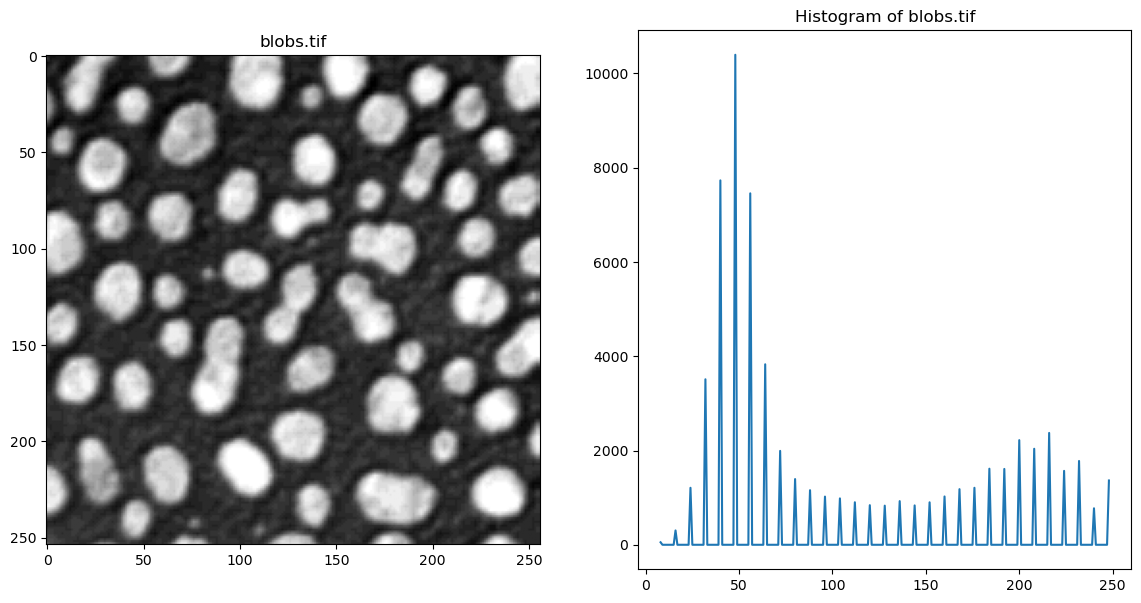

In [47]:
# Open blobs.tif
img_blobs = tifffile.imread("../../data/blobs.tif")
# plt.imshow(img_blobs, cmap="gray")

hist, bin_centers = exposure.histogram(img_blobs)

_, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(img_blobs, cmap="gray")
ax[0].set_title("blobs.tif")
ax[1].set_title("Histogram of blobs.tif")
ax[1].plot(bin_centers, hist)
# plt.plot(bin_centers, hist)
plt.show()

Use the slider in the following execution to find a good threshold to separate the blobs from the background signal.

In [40]:
@interact(threshold=(0, 255, 1))
def apply_threshold(threshold=128):
    
    # Step 1 — Select all pixels brighter than the chosen threshold
    bright_pixels = img_blobs > threshold

    # Step 2 — Convert the grayscale image to RGB so we can add colors
    overlay_image = np.stack([img_blobs] * 3, axis=-1)

    # Step 3 — Color the detected pixels red
    overlay_image[bright_pixels] = [255, 0, 0]

    # Step 4 — Show the original image and the detected pixels
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img_blobs, cmap="gray")
    ax[0].set_title("Original image")
    ax[0].axis("off")

    ax[1].imshow(overlay_image)
    ax[1].set_title(f"Pixels brighter than {threshold}")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=128, description='threshold', max=255), Output()), _dom_classes=('widget…

Manual thresholding can work well in cases where the contrast between objects and background is quite clear, like in the case above. However, this is impractical to analyse many images, or when the correct threshold is not quite as clear. Automatic thresholding can come from classic image analysis methods, such as Otsu, or from machine learning methods, such as pixel classifiers or deep learning classification. In the following sections, we will look at 2 automatic methods more closely. In Block 4, machine learning based classification methods will be shown.

### Otsu's Thresholding Method

Otsu's method analyses the histogram of pixel intensities to find the most suitable threshold value. It chooses the threshold to maximize the differecnce between background and foreground. This method is computationally inexpensive, and is often the first thresholding method used


## Filters

In general, we wish to enhance the signal-noise-ratio (SNR) as much as possible. If we try to segment a raw, noisy image, the computer will most likely identify the noisy pixels as objects, and interfere with our quantification of the actual signal of interest. By smoothing the image first, we ensure that the computer only detects real structures and signals of interest.

There are multiple types of filters, such as blurring, sharpening or edge-detection filters. In the following, we'll take a closer look at blur and sharpening filters.

### Mean / Average Filters

The average, or mean, filter is one of the simplest ways to smooth an image. This works by placing a small grid (e.g. 3x3 pixels) called a **kernel** over your image, and computing the mean of all pixel values around the center value of your grid. If there is a noisy and bright pixel in our neighborhood, we can lessen its impact on our processing by averaging over the neighboring pixels.

An illustration of a kernel operation is shown below:

![image-2.png](/home/rohang0000/IMCF/repos/mnb-image-analysis/data/mean_filter_slow.gif)

The kernel is moved over each pixel in the image. The values of the filter kernel depend on what type of kernel we are using. The average kernel of size 3x3 would look like this:

$$K = \frac{1}{9} *  \begin{bmatrix} 
1 & 1 & 1\\ 
1 & 1 & 1\\ 
1 & 1 & 1 \\
\end{bmatrix}$$



In other words: the average kernel operation adds all 9 pixels together, then divides by 9 to get the average value at each pixel entry of the image.


Let's take a look at a concrete example. In the following image, on the left, a noisy and grainy image is shown (`blobs_noisy.tif`), which is very tough for the computer to process. Using an average filter provided by `skimage`, we can average out a lot of the grainy noise. The slider defines the size of the kernel, i.e. the larger the kernel size, the bigger 


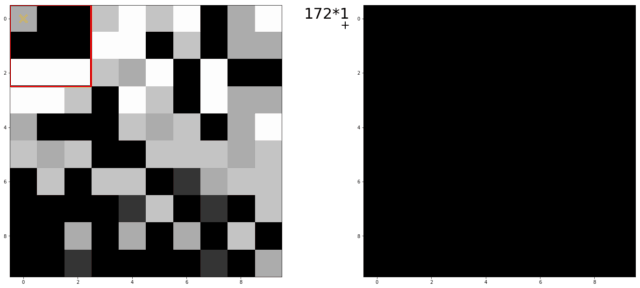
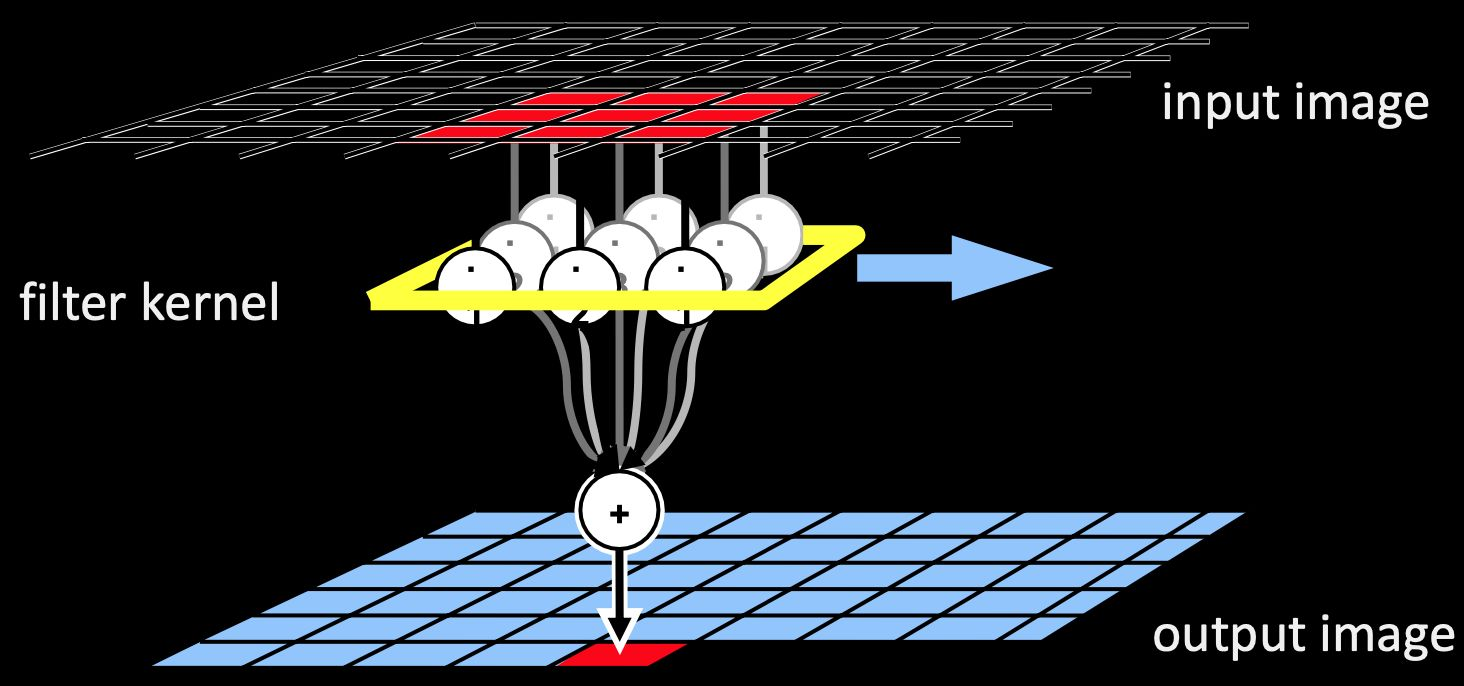

In [ ]:
# Load image once
# TODO: remove mean, keep median
noisy_blobs_image = tifffile.imread("../../data/blobs_noisy.tif")

@interact(rank_size=(2, 15, 1))
def apply_mean_filter(rank_size):

    # Define kernel size based on slider
    footprint = morphology.footprint_rectangle((rank_size, rank_size))
    
    # Apply the kernel to the image using `rank.mean(image, footprint)
    image_avg = filters.rank.mean(noisy_blobs_image, footprint)
    
    # Plotting code
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(noisy_blobs_image, cmap="gray")
    ax[0].set_title("Original: blobs_noisy.tif")
    ax[0].axis("off")
    
    ax[1].imshow(image_avg, cmap="gray")
    ax[1].set_title(f"Mean Filter ({rank_size}×{rank_size})")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()

# apply_mean_filter(3)

interactive(children=(IntSlider(value=8, description='rank_size', max=15, min=2), Output()), _dom_classes=('wi…

#### Padding

For the edge values of the image, the e.g. 3x3 kernel would "hang off" the side, meaning some of the pixels needed for the calculation are missing. To fix this, we use a technique called **padding**. We "mirror" the existing pixels at the edge to fill the gaps. This ensures the average is calculated using values similar to the real data, and that the output matches the input image size. This method is already taken care of by the methods we use in the following chapters, but can be set manually.

### The Median Filter

The median filter is another common filter used to smooth and denoise images. Instead of computing the average value of neighboring pixels, which can be susceptible to large, outlier values, the median chooses the middle value of all neighbors after sorting all pixel values.

In [3]:
@interact(rank_size=(2, 15, 1))
def apply_median_filter(rank_size):
    
    # Define kernel size based on slider
    footprint = morphology.footprint_rectangle((rank_size, rank_size))
    
    # Apply the kernel to the image using `filters.median(image, footprint)`
    image_median = filters.median(noisy_blobs_image, footprint)
    
    # Plotting code
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(noisy_blobs_image, cmap="gray")
    ax[0].set_title("Original: blobs_noisy.tif")
    ax[0].axis("off")
    
    ax[1].imshow(image_median, cmap="gray")
    ax[1].set_title(f"Median Filter ({rank_size}×{rank_size})")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=8, description='rank_size', max=15, min=2), Output()), _dom_classes=('wi…

### The Gaussian Filter

A fundamental technique is the **Gaussian Blur**. This technique also places a kernel over the image and moves it across the image, but it handles neighboring pixels differently than the mean or median filters. Instead of treating all pixels around the center equally, the Gaussian weighs nearer pixels more heavily than pixels further away. The weights follow a Gaussian distribution. In this case, pixels close to the center of the addressed pixel neighborhood influence the result strongly, while the pixels at the end of the neighborhood don't contribute as much.

In practice, the parameter that controls the filter is called $\sigma$. Smaller $\sigma$ values result in slight smoothing, while higher values result in strong blurring.

In [ ]:
@interact(sigma=(0.5,7, 0.5))
def apply_gaussian_filter(sigma):
    image_gaussian = filters.gaussian(noisy_blobs_image, sigma=sigma)

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(noisy_blobs_image, cmap="gray")
    ax[0].set_title("Original: blobs_noisy.tif")
    ax[0].axis("off")
    ax[1].imshow(image_gaussian, cmap="gray")
    ax[1].set_title(f"Gaussian Filter (sigma={sigma})")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=3.5, description='sigma', max=7.0, min=0.5, step=0.5), Output()), _dom…

We can set all three filtered images side-by-side. As the images were wrapped in interactive blocks before, we need to recompute the outputs once again. The filter size and sigma can be changed at the top of the cell.

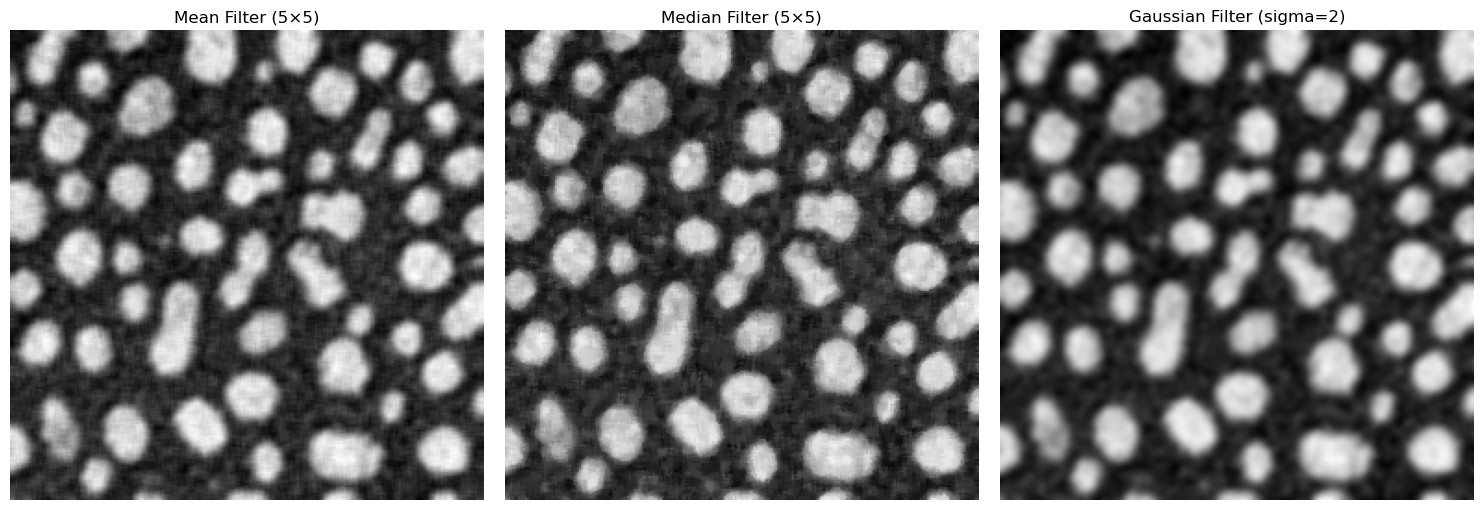

In [ ]:
kernel_size = 5
sigma = 2

# Define kernel size based on rank size
footprint = morphology.footprint_rectangle((kernel_size, kernel_size))

# Apply kernel as mean filter
image_avg = filters.rank.mean(noisy_blobs_image, footprint)
# Apply kernel as median filter
image_median = filters.median(noisy_blobs_image, footprint)

# Apply Gaussian filter
image_gaussian = filters.gaussian(noisy_blobs_image, sigma=sigma)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_avg, cmap="gray")
ax[0].set_title(f"Mean Filter ({kernel_size}×{kernel_size})")
ax[0].axis("off")
ax[1].imshow(image_median, cmap="gray")
ax[1].set_title(f"Median Filter ({kernel_size}×{kernel_size})")
ax[1].axis("off")
ax[2].imshow(image_gaussian, cmap="gray")
ax[2].set_title(f"Gaussian Filter (sigma={sigma})")
ax[2].axis("off")
plt.tight_layout()
plt.show()


## Binary Images

## Masking


## Creating Objects (ROIs)

## Measurements

## Exercise